<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=228221356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Create train and test sets
3. Train model
4. Evaluate model

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

**TODO: CLONE REPO FROM MAIN BRANCH**

In [2]:
!git clone -b feat/add-new-classes https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 308, done.
remote: Counting objects: 100% (308/308), done.
remote: Compressing objects: 100% (217/217), done.
remote: Total 308 (delta 165), reused 202 (delta 84), pack-reused 0 (from 0)
Receiving objects: 100% (308/308), 5.81 MiB | 7.60 MiB/s, done.
Resolving deltas: 100% (165/165), done.


### Imports

Use same version for central packages like [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt)

In [3]:
!pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 4.4 MB/s eta 0:00:00


In [4]:
import os
import sys
import time
import yaml
import shutil
import random
import numpy as np

import keras
from keras import layers, optimizers, losses, callbacks, saving
import kimm
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import wandb
from kaggle_secrets import UserSecretsClient

In [5]:
# add folder to sys.path so that utilities can be imported
project_dir = 'terainet'
sys.path.append(project_dir)

In [6]:
from utilities import load_config, create_class_list_yaml_file, sample_images

### Set variables and parameters

In [7]:
# load config
config_path = os.path.join(project_dir, 'config.yaml')
config = load_config(config_path)

# set num classes and class names
num_classes = config['classes']['num_classes']
class_names = [key for key in config['classes'] if key != 'num_classes']

# set seed
seed = 42

# set n train, val and test images
n_train_images = 2000
n_val_images = 300
n_test_images = 300

# set batch size
batch_size = 8

# define paths to train, val and test images
images_input_dir = config['training']['images_input_dir']
images_sampled_dir = config['training']['images_sampled_dir']
!mkdir -p "$images_sampled_dir"
train_dir = os.path.join(images_input_dir, config['training']['train_dir'])
train_sampled_dir = os.path.join(images_sampled_dir, config['training']['train_sampled_dir'])
val_sampled_dir = os.path.join(images_sampled_dir, config['training']['val_sampled_dir'])
test_dir = os.path.join(images_input_dir, config['training']['test_dir'])
test_sampled_dir = os.path.join(images_sampled_dir, config['training']['test_sampled_dir'])
test2_dir = os.path.join(images_input_dir, config['training']['test2_dir'])

# model
model_constructor = 'EfficientNetV2B0'
model_path = config['training']['model_path']
confusion_matrix_path = config['training']['confusion_matrix_path']

# decide whether to log run or not
wb_project = config['training']['wb_project']
logging = False

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [8]:
# create class list yaml file which is needed later for deployment
class_list_yaml_path = config['training']['class_list_yaml_path']
create_class_list_yaml_file(num_classes, class_names, class_list_yaml_path)

In [9]:
# log in to w&b using api key
if logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret('wandb')
    !wandb login $key

## Prepare train and test datasets

In [10]:
# create new directory with sampled train images
sample_images(train_dir, train_sampled_dir, n_train_images)

In [11]:
# create new directory with sampled test images
sample_images(test_dir, test_sampled_dir, n_test_images)

In [12]:
# create new directory with sampled validation images (use images from test_dir not included in test_sampled_dir)
sample_images(test_dir, val_sampled_dir, n_val_images, exclude_dir=test_sampled_dir)

In [13]:
# create train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_sampled_dir,
    label_mode='categorical',
    shuffle=True,
    seed=seed,
)

# create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test2 dataset
test2_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test2_dir,
    label_mode='categorical',
    shuffle=False,
)

# we need to unbatch because there's somehow an unwanted additional dimension
train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()
test_ds = test_ds.unbatch()
test2_ds = test2_ds.unbatch()

print(f'Number of train samples: {train_ds.cardinality()}')
print(f'Number of val samples: {val_ds.cardinality()}')
print(f'Number of test samples: {test_ds.cardinality()}')

Found 20000 files belonging to 10 classes.
Found 3000 files belonging to 10 classes.
Found 3000 files belonging to 10 classes.
Found 318 files belonging to 1 classes.
Number of train samples: -2
Number of val samples: -2
Number of test samples: -2


In [14]:
# check dimensions
print(train_ds.element_spec, val_ds.element_spec, test_ds.element_spec)

(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None))


In [15]:
# setup dataset with tf.data
resize_fn = keras.layers.Resizing(224, 224)

train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))
val_ds = val_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))
test2_ds = test2_ds.map(lambda x, y: (resize_fn(x), y))

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test2_ds = test2_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

## Prepare model

In [16]:
# create base model
if model_constructor == 'EfficientNetV2B0':
    base_model = kimm.models.EfficientNetV2B0(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '5M'
    frozen_file_size = '26MB'
elif model_constructor == 'EfficientNetV2B2':
    base_model = kimm.models.EfficientNetV2B2(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '9M'
    frozen_file_size = '37MB'
elif model_constructor == 'EfficientNetV2S':
    base_model = kimm.models.EfficientNetV2S(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '21M'
    frozen_file_size = '84MB'
elif model_constructor == 'EfficientNetV2M':
    base_model = kimm.models.EfficientNetV2M(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '54M'
    frozen_file_size = '216MB'
elif model_constructor == 'EfficientNetV2L':
    base_model = kimm.models.EfficientNetV2L(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '119M'
    frozen_file_size = '475MB'
elif model_constructor == 'EfficientNetV2XL':
    base_model = kimm.models.EfficientNetV2XL(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '208M'
    frozen_file_size = '835MB'
else:
    raise Exception('Please select a valid model constructor.') 

# freeze base model
base_model.trainable = False

# create new model on top
inputs = keras.Input(shape=(224, 224, 3))
x = inputs

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # regularize with dropout
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

29451563/29451563 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2B0            │ (None, 7, 7, 1280)    │  5,919,312 │   N   │
│ (EfficientNetV2B0)          │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Training

Follow [mewc-train](https://github.com/zaandahl/mewc-train)

In [17]:
df_size = int(n_train_images * num_classes)
epochs = 50
lr_init = 1e-4
min_lr_frac = 1/5 # default minimum learning rate fraction of initial learning rate
steps_per_epoch = df_size // batch_size
total_steps = epochs * steps_per_epoch # total number of steps for monotonic exponential decay across all epochs
lr = optimizers.schedules.ExponentialDecay(initial_learning_rate=lr_init, decay_steps=total_steps, decay_rate=min_lr_frac, staircase=False)
amsgrad = True
weight_decay = 1e-4
optimizer = optimizers.AdamW(learning_rate=lr, amsgrad=amsgrad, weight_decay=weight_decay)

if num_classes == 2:
  loss_f = losses.BinaryFocalCrossentropy()  # use for binary classification tasks
  act_f = 'sigmoid' # use for binary classification tasks
else:
  loss_f = losses.CategoricalFocalCrossentropy()  # use for unbalanced multi-class tasks (typical for wildlife datasets)
  act_f = 'softmax' # use for multi-class classification tasks

metrics = ['accuracy']

callbacks = [callbacks.EarlyStopping(monitor='loss', mode='min', min_delta=0.001, patience=5, restore_best_weights=True)]

In [18]:
model.compile(
    optimizer=optimizer,
    loss=loss_f,
    metrics=metrics,
)

In [19]:
start_time = time.time()
history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds)
end_time = time.time()
training_time_mins = round((end_time - start_time) / 60, 2)
print(f'Training time mins: {training_time_mins}')

Epoch 1/50


I0000 00:00:1742282899.591789      93 service.cc:145] XLA service 0x78e0d0002010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742282899.591863      93 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


     12/Unknown 16s 15ms/step - accuracy: 0.1136 - loss: 0.5015

I0000 00:00:1742282906.779378      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   2498/Unknown 63s 19ms/step - accuracy: 0.4679 - loss: 0.3031

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.4681 - loss: 0.3030 - val_accuracy: 0.6813 - val_loss: 0.1728
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7053 - loss: 0.1560 - val_accuracy: 0.7023 - val_loss: 0.1538
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7287 - loss: 0.1390 - val_accuracy: 0.7127 - val_loss: 0.1450
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7418 - loss: 0.1291 - val_accuracy: 0.7220 - val_loss: 0.1395
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7514 - loss: 0.1235 - val_accuracy: 0.7260 - val_loss: 0.1358
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7541 - loss: 0.1191 - val_accuracy: 0.7290 - val_loss: 0.1329
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7642 - loss: 0.1153 - val_accuracy: 0.7333 - val_loss: 0.1309
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.7682 - loss: 0.11

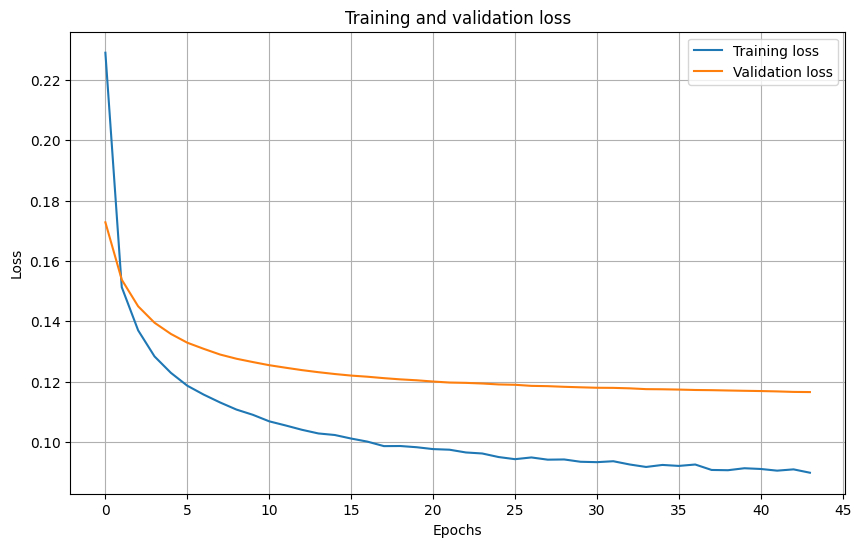

In [20]:
train_loss = history.history['loss']
val_loss = history.history.get('val_loss')

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

In [21]:
saving.save_model(model, model_path)

## Evaluation

In [22]:
test_accuracy = model.evaluate(test_ds)
print(f'Test accuracy: {test_accuracy[1] * 100:3.2f}%')

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8111 - loss: 0.0945
Test accuracy: 77.07%


In [23]:
test2_accuracy = model.evaluate(test2_ds)
print(f'Test2 accuracy: {test2_accuracy[1] * 100:3.2f}%')

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.7695 - loss: 10.1696
Test2 accuracy: 74.21%


In [24]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # append true labels based on their format
    if len(labels.shape) > 1:  # if one-hot encoded
        true_labels.append(np.argmax(labels.numpy(), axis=1))
    else:  # if integer labels
        true_labels.append(labels.numpy())

    # predict labels
    predictions = model.predict(images)
    predicted_labels.append(np.argmax(predictions, axis=1))

# combine all batches into single arrays
true_labels = np.concatenate(true_labels)
predicted_labels = np.concatenate(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━

In [25]:
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f'Precision: {precision * 100:3.2f}%; Recall: {recall * 100:3.2f}%; F1: {f1 * 100:3.2f}%')

Precision: 77.16%; Recall: 77.07%; F1: 77.06%


In [26]:
cm = confusion_matrix(true_labels, predicted_labels)
print('Confusion matrix:\n', cm)

Confusion matrix:
 [[281   4   1   0   3   4   1   3   1   2]
 [  4 180   4   6   6   6   6  50  16  22]
 [  1   8 252   4  10   8   5   3   5   4]
 [  0   4   0 265   6   9  15   0   0   1]
 [  1  16  11   7 213  20  11  10   6   5]
 [  5  12   2   5  11 234  12  10   4   5]
 [  0   7   4  15   5   4 242  10   3  10]
 [  1  17   8   5   8   4  13 213  11  20]
 [  0   9   6   3   0   3   1   8 229  41]
 [  1  19   7   2  10   5   4  19  30 203]]


In [27]:
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print('Classification report:\n', report)

Classification report:
                   precision    recall  f1-score   support

           tiger       0.96      0.94      0.95       300
         leopard       0.65      0.60      0.63       300
      black_bear       0.85      0.84      0.85       300
other_carnivores       0.85      0.88      0.87       300
            deer       0.78      0.71      0.74       300
       wild_boar       0.79      0.78      0.78       300
         buffalo       0.78      0.81      0.79       300
           rhino       0.65      0.71      0.68       300
        elephant       0.75      0.76      0.76       300
            bird       0.65      0.68      0.66       300

        accuracy                           0.77      3000
       macro avg       0.77      0.77      0.77      3000
    weighted avg       0.77      0.77      0.77      3000



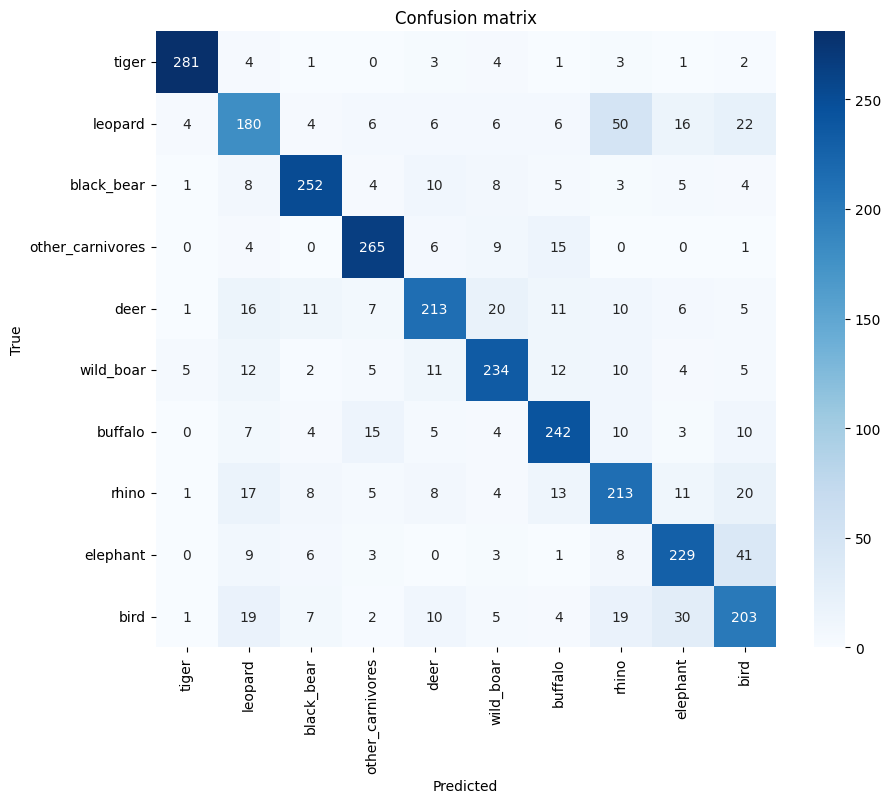

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

## Log run to W&B

In [29]:
if logging:
    run = wandb.init(
        project=wb_project,
        config={
            'model_constructor': model_constructor,
            'model_params': model_params,
            'frozen_file_size': frozen_file_size,
            'num_classes': num_classes,
            'n_train_images': n_train_images,
            'n_test_images': n_test_images,
            'batch_size': batch_size,
            'epochs': epochs,
        },
    )
    wandb.log({
        'training_time_mins': training_time_mins,
        'test_accuracy': round(test_accuracy[1], 4),
        'test2_accuracy': round(test2_accuracy[1], 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
    })
    wandb.finish()